<a href="https://colab.research.google.com/github/SikandarHussain6858/ANN-and-DL-labs/blob/main/lab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Task 0 - Notebook Setup
### Activity 0.1 – Load the dataset

In [1]:
!pip install ucimlrepo -q

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo

dataset = fetch_ucirepo(id=468)

X = dataset.data.features.copy()
y = dataset.data.targets.copy()

df = X.copy()
df["Revenue"] = y.iloc[:, 0]

df.head()


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


## Task 1 – Data Engineering and Data Understanding

Inspect whether the dataset is structured and usable before any analytical work begins.
### Activity 1.1 – Check structure and quality


In [3]:
print("Dataset shape:", df.shape)

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

df.describe(include="all").T


Dataset shape: (12330, 18)

Data types:
Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                       object
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                 object
Weekend                       bool
Revenue                       bool
dtype: object

Missing values:
Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month    

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Administrative,12330.0,NaN,NaN,NaN,2.315166,3.321784,0.0,0.0,1.0,4.0,27.0
Administrative_Duration,12330.0,NaN,NaN,NaN,80.818611,176.779107,0.0,0.0,7.5,93.25625,3398.75
Informational,12330.0,NaN,NaN,NaN,0.503569,1.270156,0.0,0.0,0.0,0.0,24.0
Informational_Duration,12330.0,NaN,NaN,NaN,34.472398,140.749294,0.0,0.0,0.0,0.0,2549.375
ProductRelated,12330.0,NaN,NaN,NaN,31.731468,44.475503,0.0,7.0,18.0,38.0,705.0
ProductRelated_Duration,12330.0,NaN,NaN,NaN,1194.74622,1913.669288,0.0,184.1375,598.936905,1464.157214,63973.52223
BounceRates,12330.0,NaN,NaN,NaN,0.022191,0.048488,0.0,0.0,0.003112,0.016813,0.2
ExitRates,12330.0,NaN,NaN,NaN,0.043073,0.048597,0.0,0.014286,0.025156,0.05,0.2
PageValues,12330.0,NaN,NaN,NaN,5.889258,18.568437,0.0,0.0,0.0,0.0,361.763742
SpecialDay,12330.0,NaN,NaN,NaN,0.061427,0.198917,0.0,0.0,0.0,0.0,1.0


## Task 2 – Data Analytics Perspective

Describe what is happening in the observed website sessions.
### Activity 2.1 – Summarize session behaviour


In [4]:
conversion_rate = df["Revenue"].mean()
print("Overall conversion rate:", round(conversion_rate * 100, 2), "%")

visitor_conversion = (
    df.groupby("VisitorType")["Revenue"]
    .mean()
    .sort_values(ascending=False)
    * 100
)
print("\nConversion by visitor type:")
print(visitor_conversion)

weekend_conversion = (
    df.groupby("Weekend")["Revenue"]
    .mean()
    * 100
)
print("\nConversion by weekend status:")
print(weekend_conversion)

print("\nBehavioral averages by Revenue:")
print(
    df.groupby("Revenue")[
        ["ProductRelated",
         "ProductRelated_Duration",
         "BounceRates",
         "ExitRates",
         "PageValues"]
    ].mean()
)


Overall conversion rate: 15.47 %

Conversion by visitor type:
VisitorType
New_Visitor          24.911452
Other                18.823529
Returning_Visitor    13.932329
Name: Revenue, dtype: float64

Conversion by weekend status:
Weekend
False    14.891144
True     17.398884
Name: Revenue, dtype: float64

Behavioral averages by Revenue:
         ProductRelated  ProductRelated_Duration  BounceRates  ExitRates  \
Revenue                                                                    
False         28.714642              1069.987809     0.025317   0.047378   
True          48.210168              1876.209615     0.005117   0.019555   

         PageValues  
Revenue              
False      1.975998  
True      27.264518  


## Task 3 – Business Intelligence Perspective
Convert observed website activity into management-oriented KPIs.
### Activity 3.1 – Build KPIs and a monthly trend chart


Total Sessions                   12330.000000
Purchasing Sessions               1908.000000
Conversion Rate (%)                 15.474453
Average Product Pages               31.731468
Average Product Page Duration     1194.746220
dtype: float64


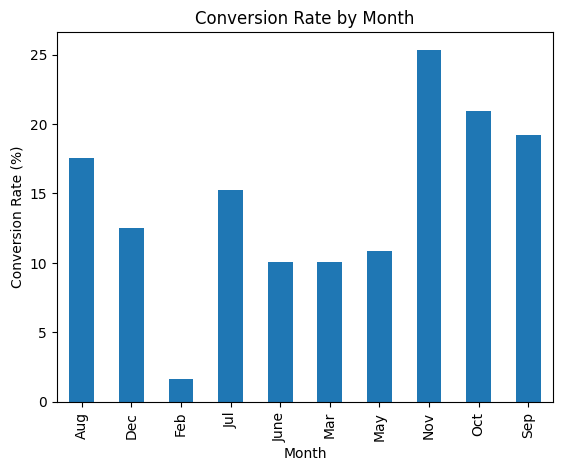

In [5]:
kpis = pd.Series({
    "Total Sessions": len(df),
    "Purchasing Sessions": df["Revenue"].sum(),
    "Conversion Rate (%)": df["Revenue"].mean() * 100,
    "Average Product Pages": df["ProductRelated"].mean(),
    "Average Product Page Duration": df["ProductRelated_Duration"].mean()
})
print(kpis)

monthly_conversion = (
    df.groupby("Month")["Revenue"]
    .mean()
    .mul(100)
)

monthly_conversion.plot(kind="bar")
plt.ylabel("Conversion Rate (%)")
plt.title("Conversion Rate by Month")
plt.show()


## Task 4 – Statistical Perspective
Move from observing a difference to evaluating whether the difference is statistically credible. Question: do weekend and weekday sessions differ in purchase behaviour?
### Activity 4.1 – Test statistical significance


In [6]:
import scipy.stats as stats

table = pd.crosstab(df["Weekend"], df["Revenue"])
print(table)

chi2, p_value, dof, expected = stats.chi2_contingency(table)

print("Chi-square statistic:", chi2)
print("p-value:", p_value)


Revenue  False  True 
Weekend              
False     8053   1409
True      2369    499
Chi-square statistic: 10.390978319534856
p-value: 0.0012663251061221968


## Task 5 – Machine Learning Perspective
Use labeled examples to learn a model that predicts whether an unseen session will generate Revenue.
### Activity 5.1 – Train and evaluate a predictive classifier


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

X_ml = df.drop(columns="Revenue")
y_ml = df["Revenue"].astype(int)

categorical_cols = X_ml.select_dtypes(
    include=["object", "category", "bool"]
).columns

numeric_cols = X_ml.select_dtypes(
    include=np.number
).columns

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

X_train, X_test, y_train, y_test = train_test_split(
    X_ml,
    y_ml,
    test_size=0.25,
    random_state=42,
    stratify=y_ml
)

model.fit(X_train, y_train)
predictions = model.predict(X_test)

print(confusion_matrix(y_test, predictions))
print(classification_report(y_test, predictions))


[[2539   67]
 [ 309  168]]
              precision    recall  f1-score   support

           0       0.89      0.97      0.93      2606
           1       0.71      0.35      0.47       477

    accuracy                           0.88      3083
   macro avg       0.80      0.66      0.70      3083
weighted avg       0.86      0.88      0.86      3083



## Task 6 – Data Mining Perspective
Ignore the target and discover behavioural structure that was not predefined. For this section, Revenue is not used to discover the groups.
### Activity 6.1 – Discover behavioural clusters


In [8]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

behavior_features = [
    "Administrative",
    "Informational",
    "ProductRelated",
    "Administrative_Duration",
    "Informational_Duration",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues"
]

X_dm = df[behavior_features]

scaler = StandardScaler()
X_dm_scaled = scaler.fit_transform(X_dm)

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(X_dm_scaled)

cluster_profiles = (
    df.groupby("Cluster")[behavior_features]
    .mean()
    .round(2)
)

print(cluster_profiles)


         Administrative  Informational  ProductRelated  \
Cluster                                                  
0                  1.00           0.18           20.93   
1                  7.05           4.00          136.99   
2                  0.03           0.01            2.62   
3                  6.30           0.90           52.50   

         Administrative_Duration  Informational_Duration  \
Cluster                                                    
0                          26.86                    7.29   
1                         262.74                  440.17   
2                           1.14                    0.00   
3                         241.83                   39.40   

         ProductRelated_Duration  BounceRates  ExitRates  PageValues  
Cluster                                                               
0                         766.10         0.01       0.04        3.34  
1                        5690.18         0.01       0.02        7.44  
2     

### Activity 6.2 – Interpret clusters against Revenue

In [9]:
cluster_revenue = (
    df.groupby("Cluster")["Revenue"]
    .mean()
    .mul(100)
)

print(cluster_revenue)


Cluster
0    11.841627
1    29.950083
2     0.541126
3    29.261587
Name: Revenue, dtype: float64


## Task 7 – Deep Learning Application Perspective
Use the same prepared session data with a supplied deep neural-network component and evaluate it as an application service. The same Online Shoppers dataset is retained so that any difference comes from the learning approach rather than from changing the problem or data.
### Activity 7.1 – Train and evaluate the Deep Learning service


In [10]:
%pip install tensorflow

              precision    recall  f1-score   support

           0      0.920     0.952     0.936      2606
           1      0.677     0.549     0.606       477

    accuracy                          0.890      3083
   macro avg      0.799     0.751     0.771      3083
weighted avg      0.883     0.890     0.885      3083

ROC-AUC: 0.905


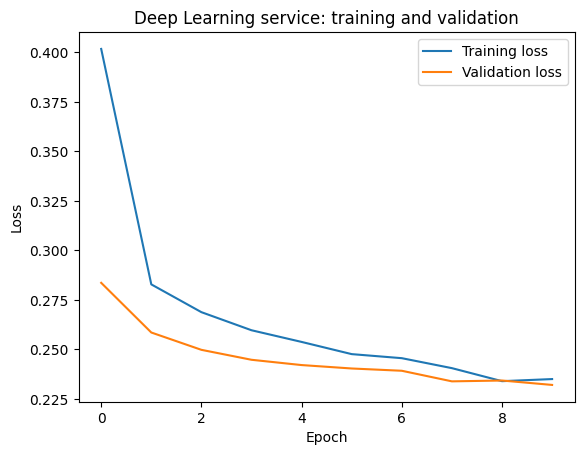

In [11]:
import tensorflow as tf
from sklearn.metrics import classification_report, roc_auc_score

X_train_dl = preprocessor.fit_transform(X_train)
X_test_dl = preprocessor.transform(X_test)
if hasattr(X_train_dl, "toarray"):
    X_train_dl = X_train_dl.toarray()
    X_test_dl = X_test_dl.toarray()

# Supplied Deep Learning application component.
# Its internal mechanisms will be studied in later labs.
dl_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train_dl.shape[1],)),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dropout(0.20),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])
dl_model.compile(optimizer="adam", loss="binary_crossentropy",
                  metrics=["accuracy"])
history = dl_model.fit(
    X_train_dl, y_train, epochs=10, batch_size=64,
    validation_split=0.20, verbose=0
)

dl_probability = dl_model.predict(X_test_dl, verbose=0).ravel()
dl_prediction = (dl_probability >= 0.50).astype(int)
print(classification_report(y_test, dl_prediction, digits=3))
print("ROC-AUC:", round(roc_auc_score(y_test, dl_probability), 3))

import matplotlib.pyplot as plt
plt.plot(history.history["loss"], label="Training loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("Deep Learning service: training and validation")
plt.legend(); plt.show()


## Task 8 – Artificial Intelligence Perspective
Use learned information inside a simple observe-decide-act loop.
### Activity 8.1 – Turn predictions into system actions


In [12]:
purchase_probability = dl_probability

def intelligent_action(probability):
    if probability >= 0.75:
        return "Recommend complementary products"
    elif probability >= 0.40:
        return "Offer browsing assistance"
    else:
        return "No intervention"

actions = [
    intelligent_action(p)
    for p in purchase_probability [:20]
]

pd.DataFrame({
    "Purchase Probability": purchase_probability[:20],
    "System Action": actions
})


,Purchase Probability,System Action
0,0.086863,No intervention
1,0.011541,No intervention
2,0.005232,No intervention
3,0.024891,No intervention
4,0.006599,No intervention
5,0.187301,No intervention
6,0.001075,No intervention
7,0.191415,No intervention
8,0.697708,Offer browsing assistance
9,0.101765,No intervention
